# 5. Graficos de negocio

Este notebook traduce el modelo de churn a graficos accionables para negocio. Usa el Random Forest final, calcula el umbral optimo con F2 (beta=2) para priorizar recall y arma la estrategia de intervencion segmentada.

In [1]:
from pathlib import Path
import json
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import fbeta_score, precision_score, recall_score

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.features.pipeline import BASE_NUMERIC_FEATURES, DERIVED_NUMERIC_FEATURES, BINARY_SEGMENT_FEATURES

FEATURES_TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "features_train.parquet"
FEATURES_TEST_PATH = PROJECT_ROOT / "data" / "processed" / "features_test.parquet"
TARGET_TEST_PATH = PROJECT_ROOT / "data" / "processed" / "target_test.csv"
TEST_RAW_PATH = PROJECT_ROOT / "data" / "processed" / "split" / "test.csv"
MODEL_PATH = PROJECT_ROOT / "outputs" / "models" / "best_rf.pkl"
THRESHOLD_CONFIG_PATH = PROJECT_ROOT / "outputs" / "models" / "threshold_f2_cv.json"
BUSINESS_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "business"
BUSINESS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
BETA = 2.0

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)


## 1. Cargar modelo y datos

In [2]:
X_train = pd.read_parquet(FEATURES_TRAIN_PATH)
X_test = pd.read_parquet(FEATURES_TEST_PATH)
y_test_df = pd.read_csv(TARGET_TEST_PATH)
test_raw = pd.read_csv(TEST_RAW_PATH)
y_test = y_test_df["Churn"].to_numpy()

with open(MODEL_PATH, "rb") as f:
    best_rf = pickle.load(f)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Churn rate test: {y_test.mean():.1%}")
print(f"Modelo cargado: {MODEL_PATH.relative_to(PROJECT_ROOT)}")

X_train: (4504, 38)
X_test:  (1126, 38)
Churn rate test: 16.9%
Modelo cargado: outputs\models\best_rf.pkl


In [3]:
# El modelo final fue entrenado con la feature kmeans_cluster.
kmeans_cols = BASE_NUMERIC_FEATURES + DERIVED_NUMERIC_FEATURES
km_final = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
km_final.fit(X_train[kmeans_cols])

X_test_model = X_test.copy()
X_test_model["kmeans_cluster"] = km_final.predict(X_test[kmeans_cols])

y_proba = best_rf.predict_proba(X_test_model)[:, 1]
print(f"Columnas usadas por el modelo: {X_test_model.shape[1]}")

Columnas usadas por el modelo: 39


## 2. Umbral F2 calibrado con cross-validation y segmentos de intervencion


In [4]:
with open(THRESHOLD_CONFIG_PATH, "r", encoding="utf-8") as f:
    threshold_config = json.load(f)

THRESHOLD_F2 = float(threshold_config["threshold"])
THRESHOLD_HIGH = 0.50
THRESHOLD_LOW = THRESHOLD_F2

# Se calculan metricas por umbral sobre test solo para visualizar el trade-off.
# El umbral usado para decidir acciones ya viene calibrado desde validacion.
threshold_candidates = np.unique(np.r_[np.linspace(0, 1, 1001), y_proba, THRESHOLD_F2])
threshold_rows = []

for threshold in threshold_candidates:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "fbeta": fbeta_score(y_test, y_pred_threshold, beta=BETA, zero_division=0),
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "clientes_contactados": int(y_pred_threshold.sum()),
    })

threshold_df = pd.DataFrame(threshold_rows)
y_pred_selected = (y_proba >= THRESHOLD_F2).astype(int)
selected_threshold_metrics = {
    "fbeta": fbeta_score(y_test, y_pred_selected, beta=BETA, zero_division=0),
    "precision": precision_score(y_test, y_pred_selected, zero_division=0),
    "recall": recall_score(y_test, y_pred_selected, zero_division=0),
}

print(f"Umbral F{BETA:g} calibrado con CV out-of-fold: {THRESHOLD_F2:.3f}")
print(
    f"CV out-of-fold - F{BETA:g}: {threshold_config['fbeta_cv_oof']:.4f} | "
    f"precision={threshold_config['precision_cv_oof']:.4f} | "
    f"recall={threshold_config['recall_cv_oof']:.4f}"
)
print(
    f"Test final - F{BETA:g}: {selected_threshold_metrics['fbeta']:.4f} | "
    f"precision={selected_threshold_metrics['precision']:.4f} | "
    f"recall={selected_threshold_metrics['recall']:.4f}"
)


Umbral F2 calibrado con CV out-of-fold: 0.318
CV out-of-fold - F2: 0.8154 | precision=0.5321 | recall=0.9406
Test final - F2: 0.8310 | precision=0.5502 | recall=0.9526


In [5]:
segment = np.select(
    [y_proba >= THRESHOLD_HIGH, y_proba >= THRESHOLD_LOW],
    ["Alta prioridad", "Media prioridad"],
    default="Sin accion",
)

business_df = test_raw.copy()
business_df["proba_churn"] = y_proba
business_df["segmento_intervencion"] = segment

segment_order = ["Alta prioridad", "Media prioridad", "Sin accion"]
segment_summary = (
    business_df.groupby("segmento_intervencion", observed=True)
    .agg(
        clientes=("CustomerID", "count"),
        churners_reales=("Churn", "sum"),
        probabilidad_media=("proba_churn", "mean"),
    )
    .reindex(segment_order)
)
segment_summary["no_churners"] = segment_summary["clientes"] - segment_summary["churners_reales"]
segment_summary["precision_segmento"] = segment_summary["churners_reales"] / segment_summary["clientes"]
segment_summary["cobertura_churners"] = segment_summary["churners_reales"] / business_df["Churn"].sum()

display(segment_summary.round(4))

,clientes,churners_reales,probabilidad_media,no_churners,precision_segmento,cobertura_churners
segmento_intervencion,,,,,,
Alta prioridad,225,161,0.7242,64,0.7156,0.8474
Media prioridad,104,20,0.4063,84,0.1923,0.1053
Sin accion,797,9,0.1039,788,0.0113,0.0474


## 3. Tamano de segmentos y churners alcanzados

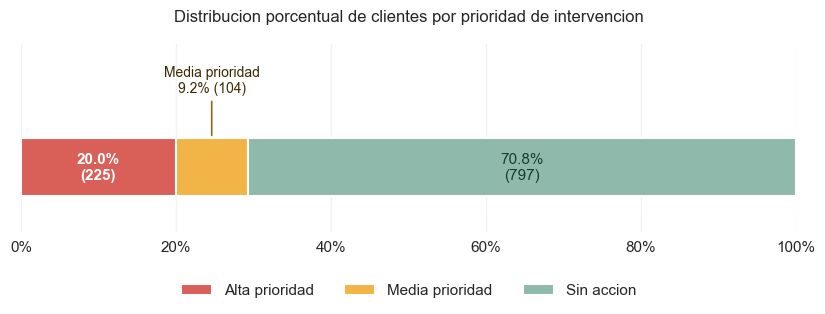

In [6]:
segment_prop = (
    segment_summary["clientes"] / segment_summary["clientes"].sum()
).reindex(segment_order)
segment_counts = segment_summary["clientes"].reindex(segment_order)

segment_colors = {
    "Alta prioridad": "#d95f59",
    "Media prioridad": "#f2b447",
    "Sin accion": "#8fb9aa",
}

fig, ax = plt.subplots(figsize=(10, 3.25))
left = 0.0
bar_y = 0
bar_height = 0.34

for segment_name in segment_order:
    width = float(segment_prop.loc[segment_name])
    count = int(segment_counts.loc[segment_name])
    center = left + width / 2
    ax.barh(
        y=bar_y,
        width=width,
        left=left,
        height=bar_height,
        color=segment_colors[segment_name],
        edgecolor="white",
        linewidth=1.5,
        label=segment_name,
    )

    label = f"{width:.1%}\n({count})"
    if width >= 0.10:
        text_color = "white" if segment_name == "Alta prioridad" else "#173b31"
        ax.text(
            center,
            bar_y,
            label,
            ha="center",
            va="center",
            color=text_color,
            fontweight="bold" if segment_name == "Alta prioridad" else "normal",
            fontsize=11,
        )
    else:
        ax.annotate(
            f"{segment_name}\n{width:.1%} ({count})",
            xy=(center, bar_y + bar_height / 2),
            xytext=(center, 0.42),
            ha="center",
            va="bottom",
            fontsize=10,
            color="#3a2a00",
            arrowprops={"arrowstyle": "-", "color": "#8a6a1f", "lw": 1.2},
        )
    left += width

ax.set_title("Distribucion porcentual de clientes por prioridad de intervencion", pad=16)
ax.set_xlim(0, 1)
ax.set_ylim(-0.38, 0.72)
ax.set_yticks([])
ax.set_xlabel("")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.tick_params(axis="x", length=0, pad=6)
sns.despine(ax=ax, left=True, bottom=True)
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.42), ncol=3, frameon=False)
fig.subplots_adjust(bottom=0.30)
plt.savefig(BUSINESS_OUTPUT_DIR / "proporcion_prioridades_intervencion.png", dpi=150, bbox_inches="tight")
plt.show()

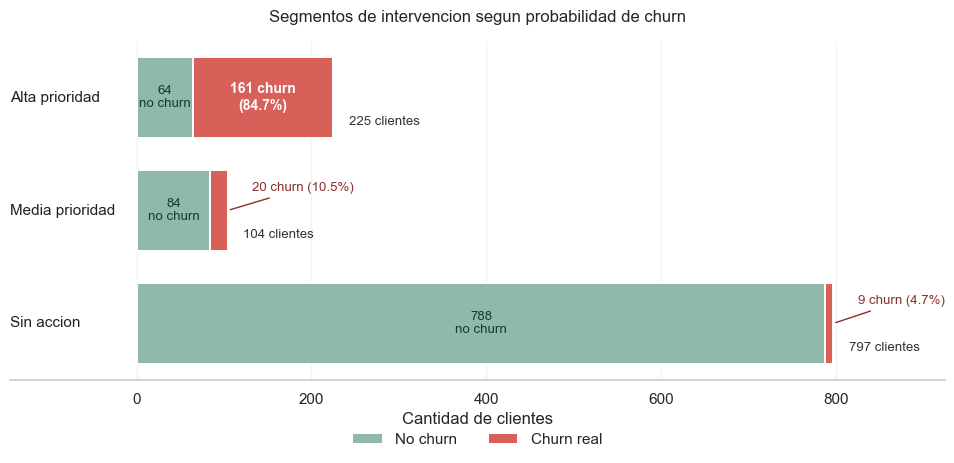

In [7]:
plot_df = segment_summary.reset_index().rename(columns={"segmento_intervencion": "segmento"})
plot_df["segmento"] = pd.Categorical(plot_df["segmento"], categories=segment_order, ordered=True)
plot_df = plot_df.sort_values("segmento", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10.5, 5.2))
y_pos = np.arange(len(plot_df))
bar_height = 0.72

ax.barh(
    y_pos,
    plot_df["no_churners"],
    color="#8fb9aa",
    edgecolor="white",
    linewidth=1.4,
    height=bar_height,
    label="No churn",
)
ax.barh(
    y_pos,
    plot_df["churners_reales"],
    left=plot_df["no_churners"],
    color="#d95f59",
    edgecolor="white",
    linewidth=1.4,
    height=bar_height,
    label="Churn real",
)

total_churners = business_df["Churn"].sum()
x_label_left = -145
for i, row in plot_df.iterrows():
    no_churn = int(row["no_churners"])
    churn = int(row["churners_reales"])
    total = int(row["clientes"])
    churn_pct = churn / total_churners

    ax.text(
        x_label_left,
        i,
        row["segmento"],
        ha="left",
        va="center",
        fontsize=11,
        color="#222222",
    )

    ax.text(
        no_churn / 2,
        i,
        f"{no_churn}\nno churn",
        ha="center",
        va="center",
        color="#173b31",
        fontsize=9.5,
    )

    if churn > 35:
        ax.text(
            no_churn + churn / 2,
            i,
            f"{churn} churn\n({churn_pct:.1%})",
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
            fontsize=10,
        )
    else:
        ax.annotate(
            f"{churn} churn ({churn_pct:.1%})",
            xy=(no_churn + churn, i),
            xytext=(no_churn + churn + 28, i + 0.20),
            ha="left",
            va="center",
            color="#8b2d2a",
            fontsize=9.5,
            arrowprops={"arrowstyle": "-", "color": "#8b2d2a", "lw": 1},
        )

    ax.text(
        total + 18,
        i - 0.22,
        f"{total} clientes",
        ha="left",
        va="center",
        fontsize=9.5,
        color="#333333",
    )

ax.set_yticks([])
ax.set_title("Segmentos de intervencion segun probabilidad de churn", pad=14)
ax.set_xlabel("Cantidad de clientes")
ax.set_ylabel("")
ax.set_xlim(x_label_left, plot_df["clientes"].max() * 1.16)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.24), ncol=2, frameon=False)
sns.despine(ax=ax, left=True)
ax.grid(axis="x", alpha=0.22)
ax.grid(axis="y", visible=False)
fig.subplots_adjust(left=0.05, bottom=0.23, right=0.94)
plt.savefig(BUSINESS_OUTPUT_DIR / "segmentos_intervencion.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Curva de cobertura de churners

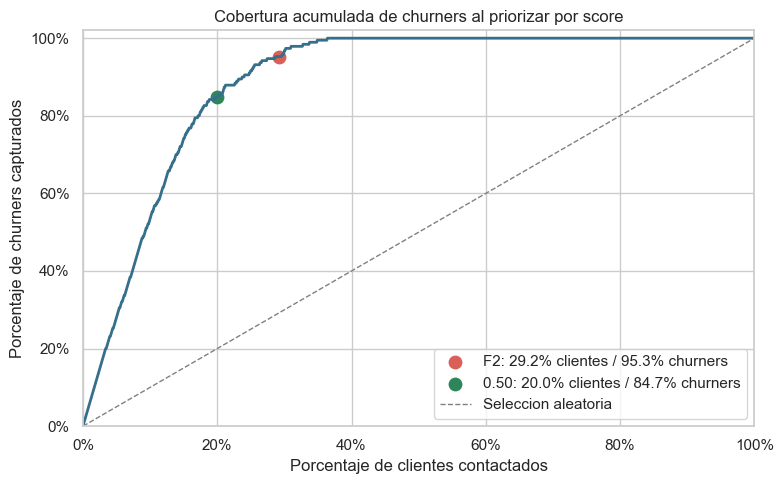

In [8]:
ranked = business_df.sort_values("proba_churn", ascending=False).reset_index(drop=True)
ranked["clientes_contactados_pct"] = (np.arange(len(ranked)) + 1) / len(ranked)
ranked["churners_capturados_pct"] = ranked["Churn"].cumsum() / ranked["Churn"].sum()

def point_for_threshold(threshold):
    contacted = ranked[ranked["proba_churn"] >= threshold]
    return len(contacted) / len(ranked), contacted["Churn"].sum() / ranked["Churn"].sum()

x_f2, y_f2 = point_for_threshold(THRESHOLD_F2)
x_050, y_050 = point_for_threshold(0.50)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ranked["clientes_contactados_pct"], ranked["churners_capturados_pct"], color="#356f8c", lw=2)
ax.scatter([x_f2], [y_f2], color="#d95f59", s=80, label=f"F2: {x_f2:.1%} clientes / {y_f2:.1%} churners")
ax.scatter([x_050], [y_050], color="#2f855a", s=80, label=f"0.50: {x_050:.1%} clientes / {y_050:.1%} churners")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Seleccion aleatoria")
ax.set_title("Cobertura acumulada de churners al priorizar por score")
ax.set_xlabel("Porcentaje de clientes contactados")
ax.set_ylabel("Porcentaje de churners capturados")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.yaxis.set_major_formatter(lambda y, pos: f"{y:.0%}")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(BUSINESS_OUTPUT_DIR / "cobertura_churners.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Trade-off precision vs recall

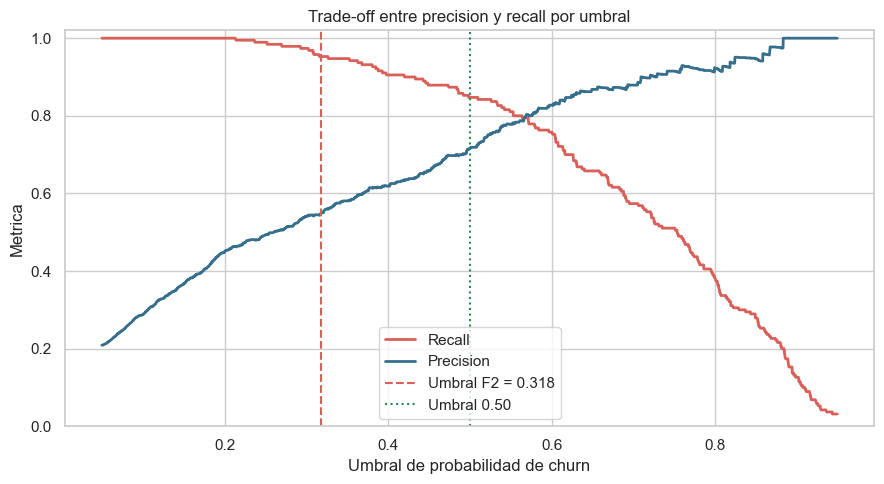

In [9]:
tradeoff = threshold_df[(threshold_df["threshold"] >= 0.05) & (threshold_df["threshold"] <= 0.95)].copy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tradeoff["threshold"], tradeoff["recall"], label="Recall", color="#d95f59", lw=2)
ax.plot(tradeoff["threshold"], tradeoff["precision"], label="Precision", color="#356f8c", lw=2)
ax.axvline(THRESHOLD_F2, color="#d95f59", linestyle="--", label=f"Umbral F2 = {THRESHOLD_F2:.3f}")
ax.axvline(0.50, color="#2f855a", linestyle=":", label="Umbral 0.50")
ax.set_title("Trade-off entre precision y recall por umbral")
ax.set_xlabel("Umbral de probabilidad de churn")
ax.set_ylabel("Metrica")
ax.set_ylim(0, 1.02)
ax.legend(loc="best")
plt.tight_layout()
plt.savefig(BUSINESS_OUTPUT_DIR / "precision_recall_umbral_f2.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Variables binarias del pipeline

Estas flags fueron generadas en `src/features/pipeline.py` para representar segmentos de negocio interpretables: clientes nuevos, leales, baja/alta frecuencia y alto valor.

In [10]:
binary_labels = {
    "is_new_customer": "Cliente nuevo",
    "is_loyal_customer": "Cliente leal",
    "is_low_freq_user": "Baja frecuencia",
    "is_high_freq_user": "Alta frecuencia",
    "is_high_value": "Alto valor",
}

binary_df = business_df[["CustomerID", "Churn", "proba_churn", "segmento_intervencion"]].copy()
for flag in BINARY_SEGMENT_FEATURES:
    raw_values = X_test[flag].copy()
    # is_high_value queda escalada por RobustScaler: original 1 -> 0, original 0 -> -1.
    if flag == "is_high_value":
        binary_df[flag] = (raw_values == 0).astype(int)
    else:
        binary_df[flag] = raw_values.astype(int)

flag_summary_rows = []
for flag in BINARY_SEGMENT_FEATURES:
    for value, label in [(1, "Si"), (0, "No")]:
        mask = binary_df[flag] == value
        flag_summary_rows.append({
            "flag": flag,
            "variable": binary_labels.get(flag, flag),
            "valor": label,
            "clientes": int(mask.sum()),
            "churners": int(binary_df.loc[mask, "Churn"].sum()),
            "tasa_churn": binary_df.loc[mask, "Churn"].mean(),
            "proba_media": binary_df.loc[mask, "proba_churn"].mean(),
            "intervenidos": int((binary_df.loc[mask, "segmento_intervencion"] != "Sin accion").sum()),
        })

flag_summary = pd.DataFrame(flag_summary_rows)
flag_summary["pct_intervenidos"] = flag_summary["intervenidos"] / flag_summary["clientes"]
display(flag_summary.round(4))

,flag,variable,valor,clientes,churners,tasa_churn,proba_media,intervenidos,pct_intervenidos
0,is_new_customer,Cliente nuevo,Si,68,12,0.1765,0.2320,15,0.2206
1,is_new_customer,Cliente nuevo,No,160,24,0.1500,0.2538,48,0.3000
2,is_loyal_customer,Cliente leal,Si,44,4,0.0909,0.2326,11,0.2500
3,is_loyal_customer,Cliente leal,No,184,32,0.1739,0.2508,52,0.2826
4,is_low_freq_user,Baja frecuencia,Si,141,25,0.1773,0.2693,43,0.3050
5,is_low_freq_user,Baja frecuencia,No,87,11,0.1264,0.2117,20,0.2299
6,is_high_freq_user,Alta frecuencia,Si,67,11,0.1642,0.2421,19,0.2836
7,is_high_freq_user,Alta frecuencia,No,161,25,0.1553,0.2495,44,0.2733
8,is_high_value,Alto valor,Si,79,15,0.1899,0.2717,25,0.3165
9,is_high_value,Alto valor,No,149,21,0.1409,0.2344,38,0.2550


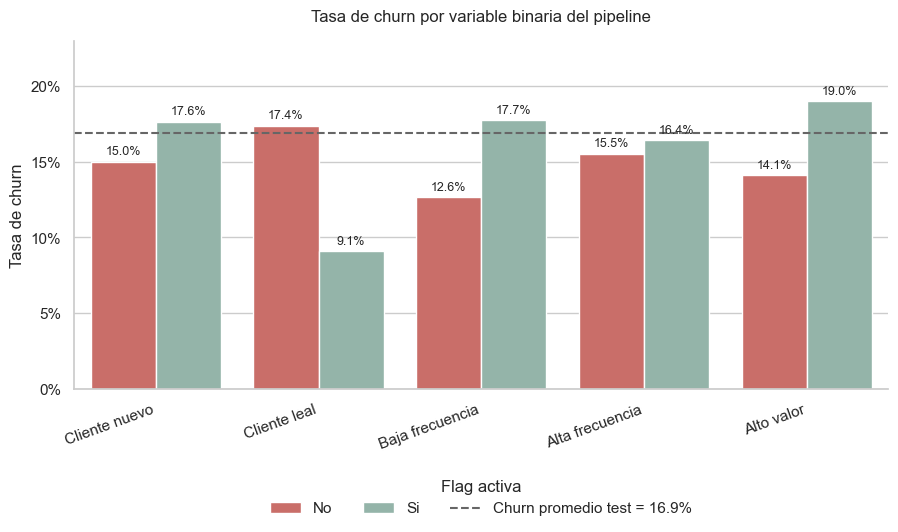

In [11]:
fig, ax = plt.subplots(figsize=(10.5, 5.8))
plot_flags = flag_summary.copy()
sns.barplot(
    data=plot_flags,
    x="variable",
    y="tasa_churn",
    hue="valor",
    order=[binary_labels[f] for f in BINARY_SEGMENT_FEATURES],
    hue_order=["No", "Si"],
    palette={"No": "#d95f59", "Si": "#8fb9aa"},
    ax=ax,
)
baseline = business_df["Churn"].mean()
baseline_line = ax.axhline(
    baseline,
    color="#666666",
    linestyle="--",
    lw=1.5,
    label=f"Churn promedio test = {baseline:.1%}",
)

for container in ax.containers:
    labels = [f"{v.get_height():.1%}" if not np.isnan(v.get_height()) else "" for v in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

ax.set_title("Tasa de churn por variable binaria del pipeline", pad=14)
ax.set_xlabel("")
ax.set_ylabel("Tasa de churn")
ax.yaxis.set_major_formatter(lambda y, pos: f"{y:.0%}")
ax.set_ylim(0, max(plot_flags["tasa_churn"].max() + 0.04, baseline + 0.04))

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    labels,
    title="Flag activa",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    frameon=False,
)

plt.xticks(rotation=20, ha="right")
sns.despine(ax=ax)
fig.subplots_adjust(bottom=0.28)
plt.savefig(BUSINESS_OUTPUT_DIR / "flags_binarias_tasa_churn.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Perfil de clientes por segmento

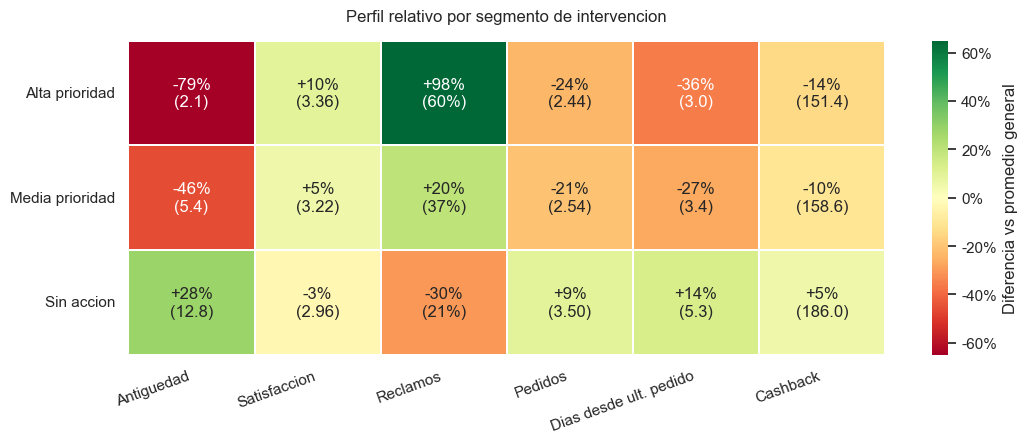

,Antiguedad,Satisfaccion,Reclamos,Pedidos,Dias desde ult. pedido,Cashback
segmento_intervencion,,,,,,
Alta prioridad,2.14,3.36,0.60,2.44,2.98,151.39
Media prioridad,5.41,3.22,0.37,2.54,3.38,158.64
Sin accion,12.81,2.96,0.21,3.50,5.26,186.03


In [12]:
profile_features = [
    "Tenure",
    "SatisfactionScore",
    "Complain",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount",
]

profile_labels = {
    "Tenure": "Antiguedad",
    "SatisfactionScore": "Satisfaccion",
    "Complain": "Reclamos",
    "OrderCount": "Pedidos",
    "DaySinceLastOrder": "Dias desde ult. pedido",
    "CashbackAmount": "Cashback",
}

profile_mean = (
    business_df.groupby("segmento_intervencion", observed=True)[profile_features]
    .mean()
    .reindex(segment_order)
)
overall_mean = business_df[profile_features].mean()

# Variacion porcentual vs promedio general: facilita ver que caracteriza a cada segmento.
profile_lift = (profile_mean / overall_mean - 1).replace([np.inf, -np.inf], np.nan)
profile_lift = profile_lift.rename(columns=profile_labels)
profile_mean_labeled = profile_mean.rename(columns=profile_labels)

annot = profile_lift.copy().astype(object)
for segment_name in profile_lift.index:
    for variable in profile_lift.columns:
        lift_value = profile_lift.loc[segment_name, variable]
        mean_value = profile_mean_labeled.loc[segment_name, variable]
        if variable == "Reclamos":
            mean_txt = f"{mean_value:.0%}"
        elif variable in ["Antiguedad", "Dias desde ult. pedido", "Cashback"]:
            mean_txt = f"{mean_value:.1f}"
        else:
            mean_txt = f"{mean_value:.2f}"
        annot.loc[segment_name, variable] = f"{lift_value:+.0%}\n({mean_txt})"

fig, ax = plt.subplots(figsize=(11, 4.6))
sns.heatmap(
    profile_lift,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    center=0,
    vmin=-0.65,
    vmax=0.65,
    linewidths=1.2,
    linecolor="white",
    cbar_kws={"label": "Diferencia vs promedio general"},
    ax=ax,
)
ax.set_title("Perfil relativo por segmento de intervencion", pad=14)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.collections[0].colorbar.ax.yaxis.set_major_formatter(lambda y, pos: f"{y:.0%}")

plt.tight_layout()
plt.savefig(BUSINESS_OUTPUT_DIR / "perfil_segmentos.png", dpi=150, bbox_inches="tight")
plt.show()

display(profile_mean_labeled.round(2))

## 8. Lista accionable para CRM

In [13]:
crm_cols = [
    "CustomerID",
    "proba_churn",
    "segmento_intervencion",
    "Churn",
    "Tenure",
    "SatisfactionScore",
    "Complain",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount",
]

crm_actions = business_df[crm_cols].sort_values("proba_churn", ascending=False)
crm_path = BUSINESS_OUTPUT_DIR / "clientes_priorizados_retencion.csv"
crm_actions.to_csv(crm_path, index=False)

print(f"Archivo CRM generado: {crm_path.relative_to(PROJECT_ROOT)}")
display(crm_actions.head(15))

Archivo CRM generado: outputs\business\clientes_priorizados_retencion.csv


,CustomerID,proba_churn,segmento_intervencion,Churn,Tenure,SatisfactionScore,Complain,OrderCount,DaySinceLastOrder,CashbackAmount
861,54288,0.984273,Alta prioridad,1,1,3.0,1.0,2,1,142.0
581,52920,0.962530,Alta prioridad,1,1,2.0,1.0,2,2,149.0
964,54870,0.962298,Alta prioridad,1,1,5.0,1.0,2,3,148.0
1075,55347,0.957459,Alta prioridad,1,1,1.0,1.0,7,8,171.0
919,54618,0.956318,Alta prioridad,1,1,4.0,1.0,2,1,144.0
154,50768,0.950538,Alta prioridad,1,0,4.0,1.0,1,0,119.0
809,54023,0.942958,Alta prioridad,1,1,1.0,1.0,2,1,149.0
243,51215,0.935119,Alta prioridad,1,0,4.0,1.0,1,0,125.0
1090,55434,0.928323,Alta prioridad,1,1,5.0,1.0,2,1,149.0
45,50199,0.928144,Alta prioridad,1,0,2.0,1.0,2,2,135.0
